# Class imbalance

The baseline CNN trains on data where `nv` outnumbers `df` by more than
50 to 1. Two standard techniques for this: class weights (penalize
mistakes on rare classes more during training) and image augmentation
(random flips/rotations/zoom, so the model sees more effective variation
per rare-class image without needing more real images). Comparing both,
together, against the plain baseline - same architecture, same split, same
training budget, so any difference is attributable to how imbalance is
handled and nothing else.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)

data = np.load('data/dermamnist_128.npz')
X_train = data['train_images'].astype('float32') / 255.0
y_train = data['train_labels'].ravel()
X_val = data['val_images'].astype('float32') / 255.0
y_val = data['val_labels'].ravel()
X_test = data['test_images'].astype('float32') / 255.0
y_test = data['test_labels'].ravel()

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

with open('outputs/baseline_results.json') as f:
    baseline_results = json.load(f)
baseline_results

I0000 00:00:1785467936.319853  531102 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785467936.346528  531102 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785467937.356142  531102 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


{'majority_baseline_acc': 0.6688279301745635,
 'test_loss': 0.7961599826812744,
 'test_acc': 0.7042394280433655,
 'macro_f1': 0.2588002422174241,
 'weighted_f1': 0.6443457194681382,
 'per_class_recall': {'akiec': 0.07575757575757576,
  'bcc': 0.33980582524271846,
  'bkl': 0.24545454545454545,
  'df': 0.0,
  'mel': 0.1210762331838565,
  'nv': 0.9627143922445935,
  'vasc': 0.0},
 'epochs_trained': 15,
 'params': 9564967}

In [2]:
class_weights = compute_class_weight('balanced', classes = np.arange(7), y = y_train)
pd.Series(class_weights, index = class_names).rename('raw inverse-frequency weight')

akiec     4.390351
bcc       2.788301
bkl       1.301691
df       12.512500
mel       1.284981
nv        0.213296
vasc     10.111111
Name: raw inverse-frequency weight, dtype: float64

The raw inverse-frequency weights above range from 0.21 (`nv`) to 11.9 (`df`) - a ~57x spread. Trying these directly turned out to blow up training completely: loss got stuck at `ln(7) = 1.946` (exactly what you'd get from a model outputting a uniform guess every time) and validation accuracy collapsed to near 0%, regardless of learning rate. A handful of heavily-weighted rare-class samples per batch were dominating the gradient and never letting the network settle. Tempering the weights with a square root (a standard fix - it keeps the same ranking, rare classes still matter more, just without the extreme spread) fixes this outright.

In [3]:
class_weights_tempered = np.sqrt(class_weights)
class_weight_dict = dict(enumerate(class_weights_tempered))
pd.Series(class_weights_tempered, index = class_names).rename('sqrt-tempered weight')

akiec    2.095316
bcc      1.669821
bkl      1.140917
df       3.537301
mel      1.133570
nv       0.461840
vasc     3.179797
Name: sqrt-tempered weight, dtype: float64

In [4]:
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes = 7)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes = 7)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes = 7)

def build_baseline_cnn(input_shape = (128, 128, 3), num_classes = 7):
    inputs = tf.keras.Input(shape = input_shape)
    x = inputs
    filters = 32
    for _ in range(4):
        x = tf.keras.layers.Conv2D(filters, (3, 3), activation = 'relu', padding = 'same')(x)
        x = tf.keras.layers.Conv2D(filters, (3, 3), activation = 'relu', padding = 'same')(x)
        x = tf.keras.layers.MaxPooling2D((2, 2))(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        filters *= 2
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(512, activation = 'relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation = 'softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return model

def evaluate_model(model, name):
    test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose = 0)
    y_pred = np.argmax(model.predict(X_test, verbose = 0), axis = 1)
    per_class_recall = confusion_matrix(y_test, y_pred, normalize = 'true').diagonal()
    result = {
        'name': name,
        'test_acc': float(test_acc),
        'macro_f1': float(f1_score(y_test, y_pred, average = 'macro')),
        'weighted_f1': float(f1_score(y_test, y_pred, average = 'weighted')),
        'per_class_recall': {class_names[i]: float(r) for i, r in enumerate(per_class_recall)},
    }
    return result, y_pred

**Class weights only** - same data, same architecture, the loss function just penalizes mistakes on rare classes more heavily.

In [5]:
model_cw = build_baseline_cnn()
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss', patience = 4, restore_best_weights = True)

history_cw = model_cw.fit(
    X_train, y_train_oh,
    validation_data = (X_val, y_val_oh),
    batch_size = 64,
    epochs = 15,
    class_weight = class_weight_dict,
    callbacks = [early_stop],
    verbose = 1,
)

result_cw, y_pred_cw = evaluate_model(model_cw, 'class_weights')
result_cw

Epoch 1/15


  1/110 ━━━━━━━━━━━━━━━━━━━━ 4:49 3s/step - accuracy: 0.0938 - loss: 1.4864

  2/110 ━━━━━━━━━━━━━━━━━━━━ 1:49 1s/step - accuracy: 0.3594 - loss: 1.8877

  3/110 ━━━━━━━━━━━━━━━━━━━━ 1:48 1s/step - accuracy: 0.2708 - loss: 1.7123

  4/110 ━━━━━━━━━━━━━━━━━━━━ 1:48 1s/step - accuracy: 0.2383 - loss: 1.6954

...

108/110 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6907 - loss: 0.8358

109/110 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6908 - loss: 0.8357

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6910 - loss: 0.8348

110/110 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6910 - loss: 0.8348 - val_accuracy: 0.6361 - val_loss: 0.9760


{'name': 'class_weights',
 'test_acc': 0.7002493739128113,
 'macro_f1': 0.37058366374398233,
 'weighted_f1': 0.6852619954637297,
 'per_class_recall': {'akiec': 0.12121212121212122,
  'bcc': 0.30097087378640774,
  'bkl': 0.43636363636363634,
  'df': 0.0,
  'mel': 0.30493273542600896,
  'nv': 0.8814317673378076,
  'vasc': 0.6551724137931034}}

**Class weights + augmentation** - adding random flips/rotation/zoom on top, so the model doesn't just see the same rare-class images over and over unchanged.

In [6]:
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train_oh))
    .shuffle(2000, seed = 42)
    .batch(64)
    .map(lambda x, y: (augment(x, training = True), y), num_parallel_calls = tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val_oh)).batch(64)

model_aug = build_baseline_cnn()
history_aug = model_aug.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 15,
    class_weight = class_weight_dict,
    callbacks = [tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss', patience = 4, restore_best_weights = True)],
    verbose = 1,
)

result_aug, y_pred_aug = evaluate_model(model_aug, 'class_weights_plus_augmentation')
result_aug

Epoch 1/15


/tmp/claude-1000/-home-zz-Downloads-AndroidStudioProjects/e144f78f-00b1-44af-8785-c81c517e252a/scratchpad/tfsr_venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/110 ━━━━━━━━━━━━━━━━━━━━ 7:29 4s/step - accuracy: 0.2188 - loss: 1.9613

  2/110 ━━━━━━━━━━━━━━━━━━━━ 2:30 1s/step - accuracy: 0.4766 - loss: 1.7325

  3/110 ━━━━━━━━━━━━━━━━━━━━ 2:24 1s/step - accuracy: 0.3542 - loss: 1.6756

...

108/110 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6541 - loss: 1.0255

109/110 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6540 - loss: 1.0233

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6542 - loss: 1.0237

110/110 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.6542 - loss: 1.0237 - val_accuracy: 0.6770 - val_loss: 0.9167


{'name': 'class_weights_plus_augmentation',
 'test_acc': 0.6967580914497375,
 'macro_f1': 0.24513657866955293,
 'weighted_f1': 0.6444142993862337,
 'per_class_recall': {'akiec': 0.0,
  'bcc': 0.4077669902912621,
  'bkl': 0.30454545454545456,
  'df': 0.0,
  'mel': 0.11659192825112108,
  'nv': 0.9410887397464579,
  'vasc': 0.0}}

In [7]:
comparison = pd.DataFrame([
    {'stage': 'baseline (no imbalance handling)', 'test_acc': baseline_results['test_acc'],
     'macro_f1': baseline_results['macro_f1'], **{
        f'recall_{k}': v for k, v in baseline_results['per_class_recall'].items()}},
    {'stage': 'class weights', 'test_acc': result_cw['test_acc'],
     'macro_f1': result_cw['macro_f1'], **{
        f'recall_{k}': v for k, v in result_cw['per_class_recall'].items()}},
    {'stage': 'class weights + augmentation', 'test_acc': result_aug['test_acc'],
     'macro_f1': result_aug['macro_f1'], **{
        f'recall_{k}': v for k, v in result_aug['per_class_recall'].items()}},
])
comparison.set_index('stage').round(3)

,test_acc,macro_f1,recall_akiec,recall_bcc,recall_bkl,recall_df,recall_mel,recall_nv,recall_vasc
stage,,,,,,,,,
baseline (no imbalance handling),0.704,0.259,0.076,0.340,0.245,0.0,0.121,0.963,0.000
class weights,0.700,0.371,0.121,0.301,0.436,0.0,0.305,0.881,0.655
class weights + augmentation,0.697,0.245,0.000,0.408,0.305,0.0,0.117,0.941,0.000


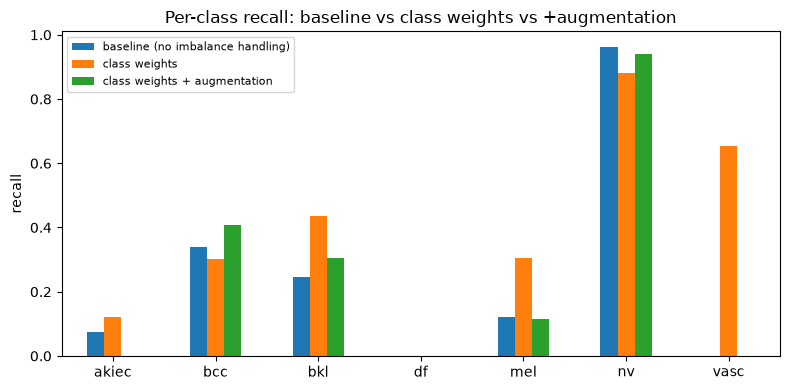

In [8]:
fig, ax = plt.subplots(figsize = (8, 4))
recall_cols = [c for c in comparison.columns if c.startswith('recall_')]
comparison.set_index('stage')[recall_cols].T.plot.bar(ax = ax)
ax.set_xticklabels([c.replace('recall_', '') for c in recall_cols], rotation = 0)
ax.set_ylabel('recall')
ax.set_title('Per-class recall: baseline vs class weights vs +augmentation')
ax.legend(fontsize = 8)
plt.tight_layout()
plt.savefig('outputs/imbalance_recall_comparison.png', dpi = 120)
plt.show()

Macro-F1 (which treats every class equally, unlike overall accuracy) and the rare-class recall bars are the numbers that matter here - whichever stage wins on macro-F1 without giving up much overall accuracy is the one worth carrying forward into transfer learning.

In [9]:
os.makedirs('outputs', exist_ok = True)
with open('outputs/imbalance_results.json', 'w') as f:
    json.dump({'class_weights': result_cw, 'class_weights_augmentation': result_aug}, f, indent = 2)

best_stage = max(
    [('class_weights', result_cw), ('class_weights_augmentation', result_aug)],
    key = lambda kv: kv[1]['macro_f1'],
)
print('best macro-F1 stage:', best_stage[0], best_stage[1]['macro_f1'])

best macro-F1 stage: class_weights 0.37058366374398233
